In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset1.csv to Dataset1 (1).csv


# **LEVEL 1: DATA OVERVIEW**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("Dataset1.csv")
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,00:00:00,06:00:00,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,08:08:00,08:10:00,199
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,09:19:00,09:21:00,312
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,12:38:00,12:40:00,577


**TASK 1.1-Data Summary**


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

Shape: (182105, 12)

Columns: Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 182105 entries, 1 to 186072
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   SN              182105 non-null  int64         
 1   Train_No        182105 non-null  int64         
 2   Station_Code    182105 non-null  object        
 3   1A              182105 non-null  int64         
 4   2A              182105 non-null  int64         
 5   3A              182105 non-null  int64         
 6   SL              182105 non-null  int64         
 7   Station_Name    182105 non-null  object        
 8   Route_Number    182105 non-null  int64         
 9   Arrival_time    182105 non-null  datetime64[ns]
 10  Departure_Time  182105 non-null  dat


I started by checking the dataset size, columns, and basic information. The dataset contains multiple records of train journeys with details like train number, station names, timings, and distance. This helped me understand the structure of the data.

**TASK 1.2-Train Routes**

In [ ]:
routes = df.groupby("Train_No").agg({
    "Station_Name": ["first", "last"]
})

routes.columns = ["Start_Station", "End_Station"]
routes = routes.reset_index()

print(routes.head())

   Train_No Start_Station   End_Station
0       107        THIVIM       KARMALI
1       108       KARMALI        THIVIM
2       128   MADGOAN JN.   CHHATRAPATI
3       290  DELHI-SAFDAR  DELHI-SAFDAR
4       401    AURANGABAD  VARANASI JN.



I analyzed how trains move between stations by grouping data based on train number. This helped me identify the starting and ending stations for each train route.

**TASK 1.3-Basic Statistics**

In [ ]:
print(df["Distance"].describe())

count    182105.000000
mean        285.805705
std         486.070712
min           0.000000
25%          24.000000
50%          76.000000
75%         300.000000
max        4260.000000
Name: Distance, dtype: float64


I checked statistical values like minimum, maximum, and average distance. I also looked at how many stops each train has. This gave me an idea of how journeys vary.

In [ ]:
stops = df.groupby("Train_No").size().reset_index(name="Total_Stops")
print(stops.head())

   Train_No  Total_Stops
0       107            2
1       108            2
2       128           22
3       290           14
4       401           12


**TASK 1.4-Missing Values**

In [ ]:
print(df.isnull().sum())

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


In [ ]:
print(df[df["Arrival_time"] == "00:00:00"].head())

Empty DataFrame
Columns: [SN, Train_No, Station_Code, 1A, 2A, 3A, SL, Station_Name, Route_Number, Arrival_time, Departure_Time, Distance]
Index: []


I checked for missing values in the dataset. Some time values were not properly recorded, which needed cleaning before further analysis.

# **LEVEL 2: CLEANING AND FEATURE ENGINEERING**

   **TASK 2.1- Data Cleaning**

In [ ]:
df = df.drop_duplicates()

df["Arrival_time"] = df["Arrival_time"].replace("00:00:00", np.nan)
df["Departure_Time"] = df["Departure_Time"].replace("00:00:00", np.nan)

df = df.dropna(subset=["Arrival_time", "Departure_Time"])

I removed duplicate records to avoid repetition. I also handled invalid time values like "00:00:00" by treating them as missing and removing those rows.

**TASK 2.2-Time Conversion**

In [ ]:
df["Arrival_time"] = pd.to_datetime(df["Arrival_time"], format="%H:%M:%S")
df["Departure_Time"] = pd.to_datetime(df["Departure_Time"], format="%H:%M:%S")

I converted arrival and departure time columns into datetime format. This step is important for calculating time differences accurately.

**Task 2.3-Journey Duration**

In [ ]:
journey = df.groupby("Train_No").agg({
    "Arrival_time": "min",
    "Departure_Time": "max"
}).reset_index()

journey["Journey_Duration"] = (
    journey["Departure_Time"] - journey["Arrival_time"]
).dt.total_seconds() / 3600

I calculated journey duration by taking the difference between departure and arrival times for each train. This became the main target variable for prediction.

**Task 2.4-Features**

In [ ]:
distance = df.groupby("Train_No")["Distance"].max().reset_index()
stops = df.groupby("Train_No").size().reset_index(name="Total_Stops")

data = journey.merge(distance, on="Train_No")
data = data.merge(stops, on="Train_No")

data.head()

,Train_No,Arrival_time,Departure_Time,Journey_Duration,Distance,Total_Stops
0,107,1900-01-01 11:06:00,1900-01-01 11:30:00,0.400000,49,2
1,108,1900-01-01 21:04:00,1900-01-01 21:28:00,0.400000,51,2
2,128,1900-01-01 00:34:00,1900-01-01 23:57:00,23.383333,978,22
3,290,1900-01-01 00:05:00,1900-01-01 22:55:00,22.833333,2694,14
4,401,1900-01-01 01:15:00,1900-01-01 23:55:00,22.666667,1618,12


I created additional features such as total distance and number of stops for each train. These features help in improving model performance.

# **LEVEL 3: DATA ANALYSIS**

**Task 3.1-Duration Comparision**

In [ ]:
data.sort_values("Journey_Duration", ascending=False).head()

,Train_No,Arrival_time,Departure_Time,Journey_Duration,Distance,Total_Stops
9829,96657,1900-01-01 00:01:00,1900-01-01 23:59:00,23.966667,57,25
10178,97435,1900-01-01 00:01:00,1900-01-01 23:59:00,23.966667,30,15
4291,37757,1900-01-01 00:01:00,1900-01-01 23:59:00,23.966667,104,24
4193,37354,1900-01-01 00:01:00,1900-01-01 23:59:00,23.966667,57,21
3760,34554,1900-01-01 00:01:00,1900-01-01 23:59:00,23.966667,45,17


I compared journey durations across different trains and found that some trains take significantly longer depending on route and stops.

**Task 3.2-Station Traffic**

In [ ]:
df["Station_Name"].value_counts().head(10)

,count
Station_Name,
CHENNAI BEAC,735
SEALDAH,729
HOWRAH JN.,676
KALYAN JN,611
DADAR,537
DUM DUM JN.,463
TAMBARAM,433
THANE,416
VIJAYWADA JN,416


I analyzed which stations have the highest number of train visits. Some stations appeared more frequently, indicating major railway hubs.

**Task 3.3-Distance vs Duration**

In [ ]:
data[["Distance", "Journey_Duration"]].corr()

,Distance,Journey_Duration
Distance,1.000000,0.774657
Journey_Duration,0.774657,1.000000


I checked the relationship between distance and journey duration. There is a clear positive relationship, meaning longer distances generally take more time.

**Task 3.4-Insights**

From the analysis, I observed that both distance and number of stops influence journey duration. These features are important for prediction.

# **LEVEL 4: VISUALIZATION**
**Task 4.1-Histogram**

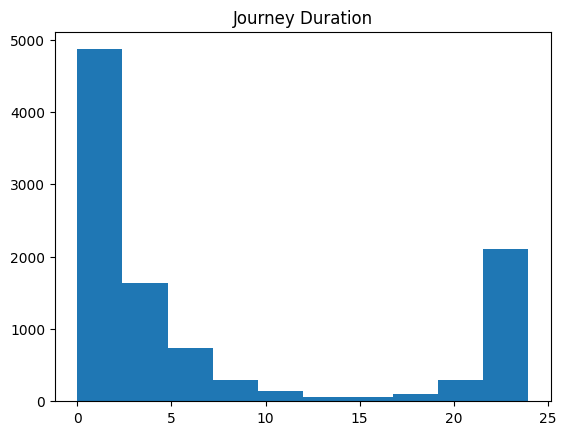

In [ ]:
plt.hist(data["Journey_Duration"])
plt.title("Journey Duration")
plt.show()

 I Plotted a histogram to understand how journey durations are distributed. Most values are concentrated in a certain range, with fewer very long journeys.

**Task 4.2-Bar Chart**

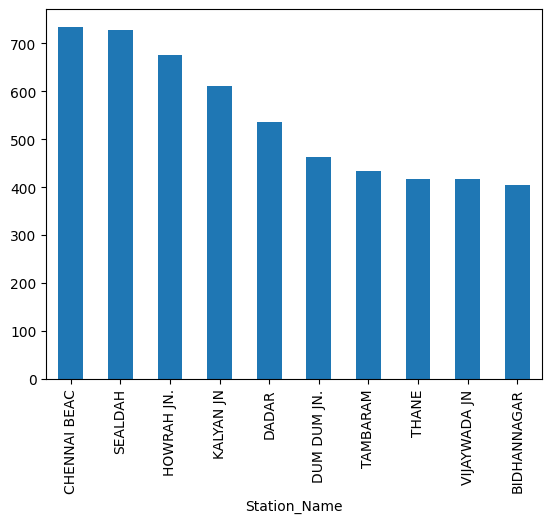

In [ ]:
df["Station_Name"].value_counts().head(10).plot(kind="bar")
plt.show()

I created a bar chart to identify stations with the highest traffic. A few stations clearly handle more trains than others.

**Task 4.3-Scatter Plot**

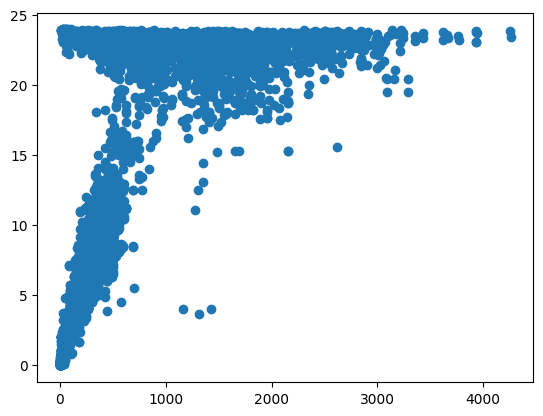

In [ ]:
plt.scatter(data["Distance"], data["Journey_Duration"])
plt.show()

I used a scatter plot to compare distance and journey duration. The upward trend confirms that as distance increases, journey time also increases.

**Task 4.4: Pattern Explanation**

From the visualizations, it is clear that distance is a major factor affecting journey duration. Trains with more stops also tend to take longer. The relationship looks mostly linear, which supports using linear regression.

# **LEVEL 5: MACHINE LEARNING**
**Task 5.1-Data Preparation**

In [ ]:
X = data[["Distance", "Total_Stops"]]
y = data["Journey_Duration"]

 I selected distance and number of stops as input features and journey duration as the target variable

**Task 5.2-Train-Test-Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

I split the dataset into training and testing sets to evaluate the model performance on unseen data.

**Task 5.3-Model Traning**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

I used Linear Regression to train the model. It learns the relationship between input features and journey duration.

**Task 5.4-Evalution**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 3.5954066189235494
RMSE: 5.434734838488402


I evaluated the model using MAE and RMSE. The results show that the model predictions are reasonably close to actual values.

# **LEVEL 6:FINAL PROJECT**
**Final Prediction System**



In the final stage of the project, I combined data analysis and machine learning to build a complete journey time prediction system. I used Linear Regression to predict the journey duration based on features like distance and number of stops. After training the model, I compared the actual and predicted values using a scatter plot. The graph shows that most predictions are close to the actual values, which indicates that the model is performing well. This step completes the full workflow from data processing to prediction and visualization.

 **Task 6.1:Final Visualization**

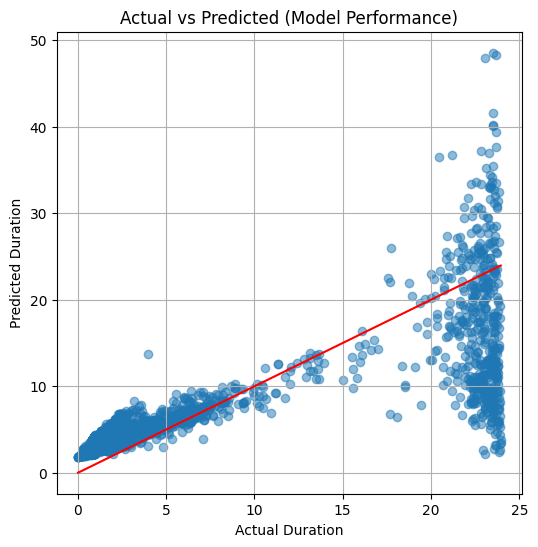

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted (Model Performance)")
plt.grid(True)
plt.show()

**Final Explanation**

I developed a prediction system using Linear Regression and evaluated its performance visually. The scatter plot of actual vs predicted values includes a reference line, which helps in understanding how close the predictions are to real values. Most data points lie near the line, showing that the model captures the trend effectively, although some variation is present.
Worked on a complete end-to-end data science project.Learned how to build and train a machine learning model.Understood how to evaluate model performance.Gained experience in data visualization
Implemented a simple prediction system